In [23]:
# dependency libararies
import warnings
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import gc

# default list for the results
from collections import defaultdict

# sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.stats import entropy
from scipy.stats import gamma

# treeple functions
import treeple
from treeple.ensemble import HonestForestClassifier, ObliqueRandomForestClassifier
from treeple.tree import ObliqueDecisionTreeClassifier
from treeple.stats import build_oob_forest
from treeple.datasets import hyppo

warnings.filterwarnings("ignore")

In [9]:


def Mix_Gaussian(
    mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
):
    """
    Generate a mixture of Gaussian dataset
    Args:
        mu_class0: mean of class 0
        mu_class1_1: mean of class 1 for the first component
        mu_class1_2: mean of class 1 for the second component
        sig: covariance matrix
        n: number of samples
        dim_info: number of informative features
        dim_total: total number of features
        mix: mixing ratio
        seed: random seed
    Returns:
        X: informative features
        X_all: all features
        y: labels
    """ 

    np.random.seed(seed)
    pdf_class0 = multivariate_normal(mean=mu_class0, cov=sig, allow_singular=True)
    pdf_class1_1 = [
        multivariate_normal(mean=mu_class1_1_i, cov=sig, allow_singular=True)
        for mu_class1_1_i in mu_class1_1
    ]
    pdf_class1_2 = [
        multivariate_normal(mean=mu_class1_2_i, cov=sig, allow_singular=True)
        for mu_class1_2_i in mu_class1_2
    ]

    n2 = [int(n * mix_i) for mix_i in mix]
    n1 = [n - n2_i for n2_i in n2]
    x_0 = [pdf_class0.rvs(size=n) for _ in range(dim_info)]
    x_1_1 = [pdf_class1_1[i].rvs(size=n1[i]) for i in range(dim_info)]
    x_1_2 = [pdf_class1_2[i].rvs(size=n2[i]) for i in range(dim_info)]
    y = np.array([0] * n + [1] * n).reshape(-1, 1)

    y = np.array([0] * n + [1] * n).reshape(-1, 1)
    X = np.zeros((2 * n, dim_info))
    for i in range(dim_info):
        X[:n, i] = x_0[i]
        X[n : (n + n1[i]), i] = x_1_1[i]
        X[(n + n1[i]) :, i] = x_1_2[i]
    X_noise = np.random.normal(0, 1, (2 * n, dim_total - dim_info))
    X_all = np.hstack((X, X_noise))

    return X, X_all, y


def Mix_Gaussian_Truth_Calculation(
    x, y, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
):
    """"
    Calculate the true posterior and s@98 for a given mixture of Gaussian dataset
    Args:
        x: informative features
        y: labels
        mu_class0: mean of class 0
        mu_class1_1: mean of class 1 for the first component
        mu_class1_2: mean of class 1 for the second component
        sig: covariance matrix
        dim_info: number of informative features
        mix: mixing ratio
    Returns:
        posterior: true posterior
        tpr_s: s@98
    """
    pdf_class0 = multivariate_normal(mean=mu_class0, cov=sig, allow_singular=True)
    pdf_class1_1 = [
        multivariate_normal(mean=mu_class1_1_i, cov=sig, allow_singular=True)
        for mu_class1_1_i in mu_class1_1
    ]
    pdf_class1_2 = [
        multivariate_normal(mean=mu_class1_2_i, cov=sig, allow_singular=True)
        for mu_class1_2_i in mu_class1_2
    ]
    prior = [0.5, 0.5]

    p_x_given_class0 = 1
    p_x_given_class1 = 1
    for d in range(dim_info):
        X = x[:, d].reshape(-1, 1)
        p_x_given_class0 *= np.nan_to_num(pdf_class0.pdf(X))
        p_x_given_class1_1 = np.nan_to_num(pdf_class1_1[d].pdf(X))
        p_x_given_class1_2 = np.nan_to_num(pdf_class1_2[d].pdf(X))
        p_x_given_class1 *= (1 - mix[d]) * p_x_given_class1_1 + mix[
            d
        ] * p_x_given_class1_2
    p_x = prior[0] * p_x_given_class0 + prior[1] * p_x_given_class1
    pos_class0 = p_x_given_class0 * prior[0] / p_x
    pos_class1 = p_x_given_class1 * prior[1] / p_x
    posterior = np.hstack((pos_class0.reshape(-1, 1), pos_class1.reshape(-1, 1)))

    fpr, tpr, thresholds = metrics.roc_curve(
        y, posterior[:, 1], pos_label=1, drop_intermediate=False
    )
    tpr_s = np.max(tpr[fpr <= 0.02])
    return posterior, tpr_s


def Gaussian_sim_truth(n, ratio, dim_info, dim_total, seed):
    np.random.seed(seed)

    n1 = int(n * ratio)
    n0 = n - n1

    mu_0 = [0 for d in range(dim_info)]
    mu_1 = [1 / np.sqrt(d) for d in range(1, dim_info + 1)]

    sig_0 = [1 for d in range(dim_info)]
    sig_1 = [2 for d in range(dim_info)]

    pdf_class0 = [
        multivariate_normal(mean=mu_0[i], cov=sig_0[i], allow_singular=True)
        for i in range(dim_info)
    ]
    pdf_class1 = [
        multivariate_normal(mean=mu_1[i], cov=sig_1[i], allow_singular=True)
        for i in range(dim_info)
    ]

    x_0 = [pdf_class0[i].rvs(n0) for i in range(dim_info)]
    x_1 = [pdf_class1[i].rvs(n1) for i in range(dim_info)]
    y = np.array([0] * n0 + [1] * n1).reshape(-1, 1)
    X = np.zeros((n, dim_info))

    for i in range(dim_info):
        X[:n0, i] = x_0[i]
        X[n0:, i] = x_1[i]
    X_noise = np.random.normal(0, 1, (n, dim_total - dim_info))
    X_all = np.hstack((X, X_noise))

    pdf_class0 = [
        multivariate_normal(mean=mu_0[i], cov=sig_0[i], allow_singular=True)
        for i in range(dim_info)
    ]
    pdf_class1 = [
        multivariate_normal(mean=mu_1[i], cov=sig_1[i], allow_singular=True)
        for i in range(dim_info)
    ]
    prior = [1 - ratio, ratio]

    p_x_given_class0 = 1
    p_x_given_class1 = 1
    for d in range(dim_info):
        x = X[:, d].reshape(-1, 1)
        p_x_given_class0 *= np.nan_to_num(pdf_class0[d].pdf(x))
        p_x_given_class1 *= np.nan_to_num(pdf_class1[d].pdf(x))
    p_x = prior[0] * p_x_given_class0 + prior[1] * p_x_given_class1
    pos_class0 = p_x_given_class0 * prior[0] / p_x
    pos_class1 = p_x_given_class1 * prior[1] / p_x
    posterior = np.hstack((pos_class0.reshape(-1, 1), pos_class1.reshape(-1, 1)))

    fpr, tpr, thresholds = metrics.roc_curve(
        y, posterior[:, 1], pos_label=1, drop_intermediate=False
    )
    tpr_s = np.max(tpr[fpr <= 0.02])

    return X_all, y, posterior, tpr_s


def Calculate_MI(y_true, y_pred_proba):
    H_YX = np.mean(entropy(y_pred_proba, base=np.exp(1), axis=1))
    # empirical count of each class (n_classes)
    _, counts = np.unique(y_true, return_counts=True)
    H_Y = entropy(counts, base=np.exp(1))
    return H_Y - H_YX

Running experiment for dim: 100, n: 1000
X_test_all [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
true_posterior_test [[0.5 0.5]
 [0.5 0.5]]


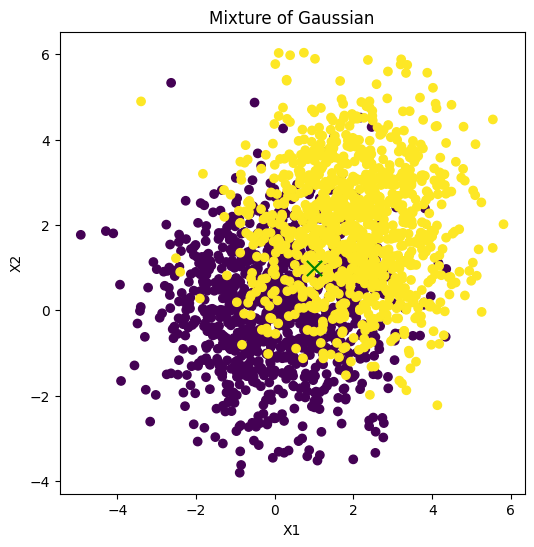

Running HonestForestClassifier
[0.52709568 0.47290432]
Running RandomForestClassifier with isotonic
[0.62400536 0.37599464]
Running RandomForestClassifier with sigmoid
[0.87203409 0.12796591]
Running LogisticRegression with isotonic
[0.40154732 0.59845268]
Running LogisticRegression with sigmoid
[0.4873965 0.5126035]
Running SVC with isotonic
[0.49018586 0.50981414]
Running SVC with sigmoid
[0.53631529 0.46368471]
Running GradientBoostingClassifier with isotonic
[0.70090219 0.29909781]
Running GradientBoostingClassifier with sigmoid
[0.61990493 0.38009507]
Running experiment for dim: 100, n: 1000
X_test_all [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
true_posterior_test [[0.5 0.5]
 [0.5 0.5]]
Running HonestForestClassifier
[0.46

In [179]:
import json
import os
from collections import defaultdict
import time
from sklearn.exceptions import ConvergenceWarning
import test

# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.ensemble._forest")

CWD_DIR = !pwd
DIRECTORY = CWD_DIR[0] 
MODEL_DIR = CWD_DIR[0]
N_JOBS = 50
# N_EST = [100, 1000, 10_000,100_000] # 100_000
N_EST = 10000
MAX_SAMPLES = 1.6
RANDOM_STATE = np.random.randint(0, 1000)
N_TEST = 100
RESULTS_FILE = f"Fig_calibration_{N_EST}EST.json"
HONEST_FRACTION = 0.36
MAX_FEAURES = "sqrt"
HONEST_PRIOR = "ignore"
HONEST_METHOD = "apply"
N_CV = 5
PLOT = False

# Set up the experiments
# DIMS = [2, 10, 50, 100, 500, 1000]
DIMS = [100]
DIM_INFO = 10
MIX = [1/DIM_INFO for i in range(DIM_INFO)]
# SAMPLE_SIZE = [100, 1000, 5000, 10000, 50000, 100000]
SAMPLE_SIZE = [1000]
METHODS = ['isotonic', 'sigmoid']
N_REPEATS = 10
MU_CLASS0 = 0
MU_CLASS1 = 2
SIG = 2

def log_results(log):
     # Convert NumPy arrays to lists
    for key, value in log.items():
        if isinstance(value, np.ndarray):
            log[key] = value.tolist()
    file_path = os.path.join(DIRECTORY, RESULTS_FILE)
    if RESULTS_FILE not in os.listdir(DIRECTORY):
        # Save the kwargs as JSON
        with open(file_path, 'w') as json_file:
            json.dump([log], json_file, indent=4)  # Save as a list containing the first entry
    else:
        # Append the results to the file
        with open(file_path, 'r+') as json_file:
            try:
                data = json.load(json_file)
            except json.JSONDecodeError:
                data = []  # Initialize with an empty list if the file is empty or invalid
            data.append(log)
            json_file.seek(0)
            json.dump(data, json_file, indent=4)
    # return log

SPORF = HonestForestClassifier(
    n_estimators=N_EST,
    max_samples=MAX_SAMPLES,
    honest_fraction=HONEST_FRACTION,
    max_features=MAX_FEAURES,
    bootstrap=True,
    stratify=True,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    honest_prior=HONEST_PRIOR,
    honest_method=HONEST_METHOD,
    tree_estimator=ObliqueDecisionTreeClassifier(),
            )

RF = RandomForestClassifier(
    n_estimators=int(N_EST/N_CV),
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
)

LR = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

# SVM classifier
SVM = SVC(
    probability=True,
    random_state=RANDOM_STATE,
)

# Gradient Boosting classifier
GB = GradientBoostingClassifier(
    n_estimators=int(N_EST/N_CV),
    random_state=RANDOM_STATE,
)

LOGS = []
for rep in range(N_REPEATS):
    if rep == 0:
        PLOT = True
    else:
        PLOT = False
    RANDOM_STATE = np.random.randint(0, 1000)
    for dim in DIMS:
        for n in SAMPLE_SIZE:
            print(f"Running experiment for dim: {dim}, n: {n}")
            # generate the dataset
            dim_info = DIM_INFO
            mu_class0 = [MU_CLASS0]
            mu_class1_1 = [MU_CLASS1 for d in range(dim_info)]
            mu_class1_2 = [MU_CLASS1 for d in range(dim_info)]
            sig = test_sig = SIG
            dim_total = dim
            mix = MIX
            seed = RANDOM_STATE
            X_train, X_train_all, y_train = Mix_Gaussian(
                mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
            )
            # print(X_train.shape, X_train_all.shape, y_train.shape)
            true_posterior_train, tpr_s = Mix_Gaussian_Truth_Calculation(
                X_train, y_train, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
            )
            # genetate a test dataset from the intersection of the two classes
            # test_mu_class1_1 = [x / 2 for x in mu_class1_1]
            # test_mu_class1_2 = [x / 2 for x in mu_class1_2]
            # X_test, X_test_all, y_test = Mix_Gaussian(
            #     mu_class0, test_mu_class1_1, test_mu_class1_2, test_sig, n_test, dim_info, dim_total, mix, seed
            # )
            test_mu_class0 = test_mu_class1 = (MU_CLASS1 - MU_CLASS0) / 2
            X_test= np.array([(MU_CLASS1 - MU_CLASS0 )/ 2 for x in range(dim_info)])
            X_test_all = np.hstack((X_test, [0 for x in range(dim_total - dim_info)]))
            # stack 2 samples for the test dataset
            X_test_all = np.vstack((X_test_all, X_test_all))
            y_test = np.array([0, 1])
            true_posterior_test, tpr_s = Mix_Gaussian_Truth_Calculation(
                X_test_all, y_test, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
            )
            print( "X_test_all", X_test_all[0])
            # print("true_posterior_train", true_posterior_train)
            print("true_posterior_test", true_posterior_test)
            if PLOT:
                # plot the test dataset on the same plot
                plt.figure(figsize=(6, 6))
                plt.scatter(X_train_all[:, 0], X_train_all[:, 1], c=y_train.flatten())
                plt.scatter(X_test_all[1,0], X_test_all[1,1], c='green', marker='x', s=120)
                plt.xlabel("X1")
                plt.ylabel("X2")
                plt.title("Mixture of Gaussian")
                plt.show()

            # run the experiment
            for model in [SPORF, RF, LR, SVM, GB]:
                result = {}
                result['model'] = model.__class__.__name__
                result['dim'] = dim
                result['n'] = n
                result['mu_class0'] = mu_class0
                result['mu_class1_1'] = mu_class1_1
                result['mu_class1_2'] = mu_class1_2
                result['sig'] = sig
                result['mix'] = mix
                result['seed'] = seed
                model_name = model.__class__.__name__
                result['model'] = model_name
                if model_name == "HonestForestClassifier":
                    print(f"Running {model_name}")
                    result['method'] = "HonestForest"
                    # start time
                    start_time = time.perf_counter()
                    # obtain tree level posteriors
                    fitted_model, tree_proba = build_oob_forest(model, X_train_all, y_train)
                    # calculate fitting time
                    end_time = time.perf_counter()
                    # calculate fitting time
                    result['fit_time'] = end_time - start_time
                    # predict on the test set
                    posterior = fitted_model.predict_proba(X_test_all)
                    result['posterior'] = posterior.tolist()
                    # get the metrics and log the results
                    y_pred = np.argmax(posterior, axis=1)
                    result['y_pred'] = y_pred
                    y_true = y_test #.flatten()
                    # calculate the metrics
                    accuracy = accuracy_score(y_true, y_pred)
                    result['accuracy'] = accuracy
                    auc = roc_auc_score(y_true, posterior[:, 1])
                    result['auc'] = auc
                    f1 = f1_score(y_true, y_pred)
                    result['f1'] = f1
                    precision = precision_score(y_true, y_pred)
                    result['precision'] = precision
                    recall = recall_score(y_true, y_pred)
                    result['recall'] = recall
                    mi = Calculate_MI(y_true, posterior)
                    result['mi'] = mi
                    # log the results
                    log_results(result)
                    print(posterior[0])
                else:
                    # do 5-fold cross validation with CalibratedClassifierCV
                    for method in METHODS:
                        result['method'] = method
                        print(f"Running {model_name} with {method}")
                        cv = StratifiedKFold(n_splits=N_CV, shuffle=True, random_state=RANDOM_STATE)
                        # start time
                        start_time = time.perf_counter()
                        # fit the model
                        model = CalibratedClassifierCV(estimator=model, cv=cv, method=method, n_jobs=N_JOBS)
                        model.fit(X_train_all, y_train.flatten())
                        # calculate fitting time
                        end_time = time.perf_counter()
                        # calculate fitting time
                        fit_time = end_time - start_time
                        result['fit_time'] = fit_time
                        # predict on the test set
                        posterior = model.predict_proba(X_test_all)
                        result['posterior'] = posterior.tolist()
                        # get the metrics and log the results
                        y_pred = np.argmax(posterior, axis=1)
                        result['y_pred'] = y_pred
                        y_true = y_test #.flatten()
                        # calculate the metrics
                        accuracy = accuracy_score(y_true, y_pred)
                        result['accuracy'] = accuracy
                        auc = roc_auc_score(y_true, posterior[:, 1])
                        result['auc'] = auc
                        f1 = f1_score(y_true, y_pred)
                        result['f1'] = f1
                        precision = precision_score(y_true, y_pred)
                        result['precision'] = precision
                        recall = recall_score(y_true, y_pred)
                        result['recall'] = recall
                        mi = Calculate_MI(y_true, posterior)
                        result['mi'] = mi
                        # log the results
                        log_results(result)
                        print(posterior[0])



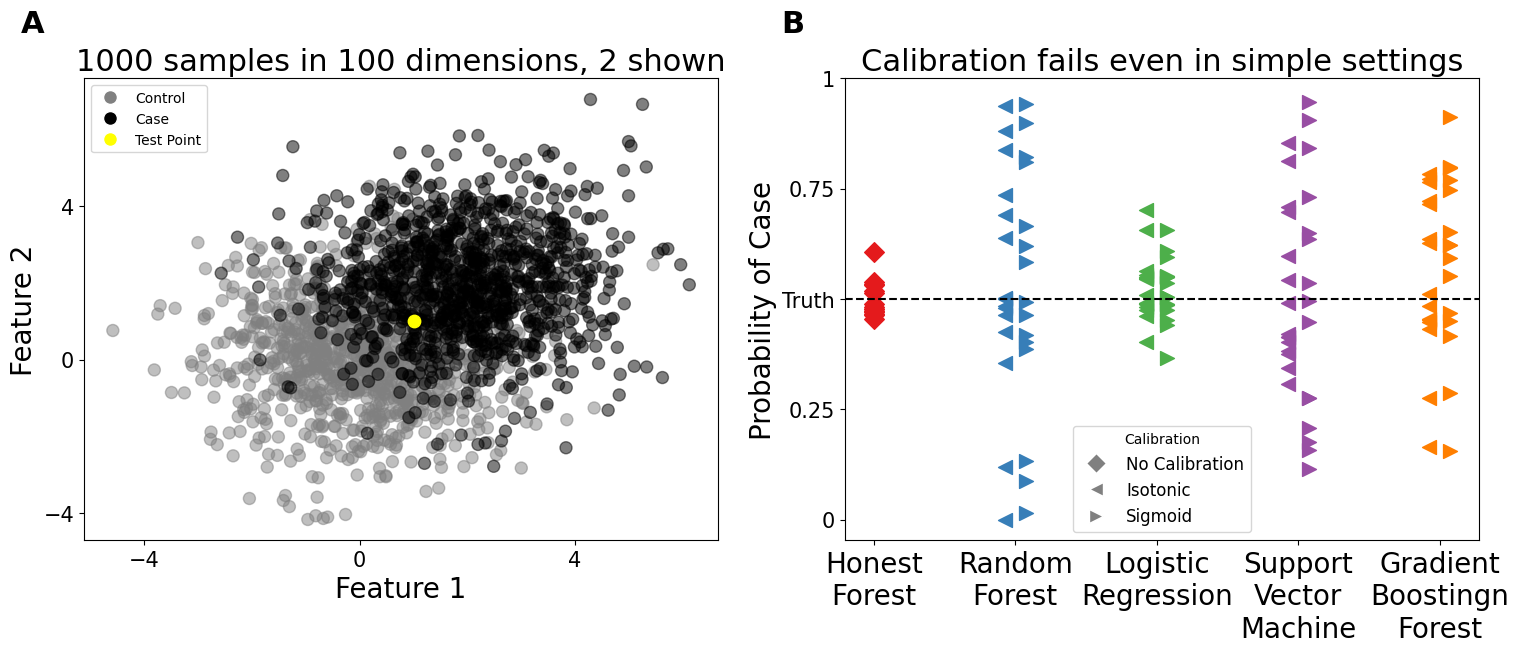

In [200]:
# for plottin the results
from tkinter import font
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

def plot_gaussian_mixture(
    mu_class0,
    mu_class1_1,
    mu_class1_2,
    sig,
    n,
    dim_info,
    dim_total,
    mix,
    seed,
    axs=None,
):
    X, X_all, y = Mix_Gaussian(
        mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
    )
    # print(X.shape, X_all.shape, y.shape)
    test_mu_class0 = test_mu_class1 = (mu_class1_1[0] - mu_class0[0]) / 2
    mu_test = (mu_class1_1[0] - mu_class0[0]) / 2
    X_test = np.array([mu_test for x in range(dim_info)])
    X_test_all = np.hstack((X_test, [0 for x in range(dim_total - dim_info)]))
    # stack 2 samples for the test dataset
    X_test_all = np.vstack((X_test_all, X_test_all))
    y_test = np.array([0, 1])
    true_posterior_test, tpr_s = Mix_Gaussian_Truth_Calculation(
        X_test_all, y_test, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
    )
    # genetate a test dataset from the intersection of the two classes
    # test_mu_class0 = test_mu_class1 = [(MU_CLASS1 - MU_CLASS0) / 2 for x in range(dim_info)]
    # X_test, y_test = [
    #     [test_mu_class0, 0],
    #     [test_mu_class1, 0],
    # ], [0, 1]
    # X_noise = np.random.normal(0, 1, (2, dim_total - dim_info))
    # X_test_all = np.hstack((X_test, X_noise))
    # print(test_X.shape, test_X_all.shape, test_y.shape)
    custom_cmap = ListedColormap(["gray", "black"])
    if axs is not None:
        scatter = axs.scatter(
            X_all[:, 0],
            X_all[:, 1],
            c=y.flatten(),
            alpha=0.5,
            # set color to "gray" for class 0 and "black" for class 1
            cmap=custom_cmap,
            s=75,
        )
        # axs.scatter(test_X_all[:, 0], test_X_all[:, 1], c="green")
        axs.scatter(
            X_test_all[0][0],
            X_test_all[0][1],
            c="yellow",
            marker="o",
            s=80,
            label="Test Point",
            alpha=1,
        )
        axs.set_xlabel("Feature 1", fontsize=20)
        axs.set_xticks([-4, 0, 4])
        axs.set_ylabel("Feature 2", fontsize=20)
        axs.set_yticks([-4, 0, 4])
        # add subtitle
        # axs.text(
        #     0.5,
        #     -0.15,
        #     f"Control: N({mu_class0[0]}, {sig})^{dim_info}, Case : N({mu_class1_1[0]}, {sig})^{dim_info}",
        #     horizontalalignment="center",
        #     verticalalignment="center",
        #     transform=axs.transAxes,
        #     fontsize=16,
        #     color="black",
        # )
        # Create custom legend handles
        legend_handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Control'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Case'),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="yellow",
                markersize=10,
                label="Test Point",
            ),
        ]

        # Add legend to the plot

        axs.legend(handles=legend_handles)
        axs.set_title(f"{n} samples in {dim_total} dimensions, 2 shown", fontsize=22)
    else:
        # plot the test dataset on the same plot
        plt.figure(figsize=(6, 6))
        plt.scatter(
            X_all[:, 0],
            X_all[:, 1],
            c=y.flatten(),
            alpha=0.5,
            s=100,
        )
        plt.scatter(
            X_test_all[0],
            X_test_all[1],
            c="yellow",
            marker="o",
            s=100,
            label="Test Point",
            alpha=1,
        )
        plt.xlim(min(X_all[:, 0]) - 1, max(X_all[:, 0]) + 1)
        # add custom ticks at [-4, 0, 4]
        plt.xticks([-4, 0, 4])
        plt.ylim(min(X_all[:, 1]) - 1, max(X_all[:, 1]) + 1)
        plt.yticks([-4, 0, 4])
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title(f"Simulated Data: {n} samples", fontsize=22)
        # add subtitle
        plt.text(
            0.5,
            0.1,
            f"Class 0: N({mu_class0[0]}, {sig})^{dim_info}, Class 1 : N({mu_class1_1[0]}, {sig})^{dim_info}",
            horizontalalignment="center",
            verticalalignment="center",
        )
        plt.legend()
        plt.show()
    posterior, tpr_s = Mix_Gaussian_Truth_Calculation(
        X_test_all,
        y_test,
        mu_class0,
        mu_class1_1,
        mu_class1_2,
        test_sig,
        dim_info,
        mix,
    )
    y_pred = np.argmax(posterior, axis=1)
    mi_truth = Calculate_MI(y, posterior)
    return mi_truth, posterior, tpr_s

RESULTS_FILE = f"Fig_calibration.json"
# for each row calculate the mi
filename = RESULTS_FILE
df = pd.read_json(filename)
# MI = []
y_pred_probas = []
for i in range(len(df)):
    row = df.iloc[i]
    posterior = np.array(row["posterior"])
    y_pred_proba = np.array(row["posterior"])[:, 0][1]
    y_pred_probas.append(y_pred_proba)
    n = posterior.shape[0]
    # generate the y_true
    y_true = [0] * (n // 2) + [1] * (n // 2)
    
    # get the mi
#     mi = Calculate_MI(y_true, posterior)
#     MI.append(mi)
# df["MI"] = MI
df["y_pred_proba"] = y_pred_probas

# plot the y_pred_proba in boxplot with scatter for each model in x-axis
# create a map of the models to its labels
model_labels = {
    "HonestForestClassifier": "Honest\nForest",
    "RandomForestClassifier": "Random\nForest",
    "LogisticRegression": "Logistic\nRegression",
    "SVC": "Support\nVector\nMachine",
    "GradientBoostingClassifier": "Gradient\nBoostingn\nForest",
}
# crete a color map for each model in Set1 for descrete 1 to 6
colors = plt.cm.Set1.colors
models = df["model"].unique()
methods = ["isotonic", "sigmoid"]
dim_info = DIM_INFO
mu_class0 = [MU_CLASS0]
mu_class1_1 = [MU_CLASS1 for d in range(dim_info)]
mu_class1_2 = [MU_CLASS1 for d in range(dim_info)]
sig = test_sig = SIG
dim_total = DIMS[0]
mix = MIX
n = 1000
seed = 42

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
_, _, _ = plot_gaussian_mixture(
    mu_class0,
    mu_class1_1,
    mu_class1_2,
    sig,
    n,
    dim_info,
    dim_total,
    mix,
    seed,
    axs=ax[0],
)
for i, model in enumerate(models):
    if model == "HonestForestClassifier":
        method = "HonestForest"
        y_pred_proba = df[(df["model"] == model) & (df["method"] == method)][
            "y_pred_proba"
        ]
        ax[1].scatter(
            [i] * len(y_pred_proba),
            y_pred_proba,
            label=model_labels[model],
            color=colors[0],
            s=100,
            marker="D",
        )
        # ax[1].boxplot(y_pred_proba, positions=[i], showfliers=False)
    else:
        for j, method in enumerate(methods):
            # change marker for each method
            if method == "isotonic":
                marker = "<"
                label = model_labels[model]
                jitter = -0.075
            else:
                marker = ">"
                label = None
                jitter = 0.075
            y_pred_proba = df[(df["model"] == model) & (df["method"] == method)][
                "y_pred_proba"
            ]
            ax[1].scatter(
                [i + jitter] * len(y_pred_proba),
                y_pred_proba,
                label=label,
                marker=marker,
                color=colors[i],
                s=100,
            )
            # ax[1].boxplot(y_pred_proba, positions=[i], showfliers=False)
ax[0].tick_params(axis="both", which="major", labelsize=15)
ax[1].tick_params(axis="both", which="major", labelsize=15)
# add a vline at y=0.5
ax[1].axhline(y=0.5, color="black", linestyle="--", label="Truth")
ax[1].set_xticks(range(len(models)))
ax[1].set_xticklabels(model_labels.values(), rotation=0, fontsize=20)
# ax[1].set_xlabel("Model", fontsize=16)
ax[1].set_ylabel("Probability of Case", fontsize=20)
# set custom y_ticks at [0.25, 0.5, 0.75] with tick labels [0.25, "Truth", 0.75]
ax[1].set_yticks([0, 0.25, 0.5, 0.75, 1])
ax[1].set_yticklabels([0, 0.25, "Truth", 0.75, 1])
# add a title
ax[1].set_title("Calibration fails even in simple settings", fontsize=22)
# add marker for each method in the legend i.e. o for isotonic and x for sigmoid
# Create custom legend handles
# scatter_isotonic = ax[1].scatter(
#     -0,
#     -0,
#     c="gray",
#     marker="o",
#     label="Isotonic",
#     alpha=0.0
# )
# scatter_sigmoid = ax[1].scatter(
#    -0, -0, c="gray", marker="x", label="Sigmoid", alpha=0.0
# )
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="gray",
        markersize=10,
        label="No Calibration",
    ),
    Line2D(
        [0],
        [0],
        marker="<",
        color="w",
        markerfacecolor="gray",
        markersize=10,
        label="Isotonic",
    ),
    Line2D(
        [0],
        [0],
        marker=">",
        color="w",
        markerfacecolor="gray",
        markersize=10,
        label="Sigmoid",
    ),
]
# add label for each plot
ax[0].text(-0.1, 1.1, "A", transform=ax[0].transAxes, fontsize=22, fontweight="bold")
ax[1].text(-0.1, 1.1, "B", transform=ax[1].transAxes, fontsize=22, fontweight="bold")
plt.legend(handles=legend_handles, title="Calibration", loc="lower center", fontsize=12)
# move the legend outside the plot
# plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

## TabPFN

In [ ]:
# !pip install tabpfn
# !pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.2 MB/s eta 0:00:00a 0:00:01


In [204]:
from tabpfn import TabPFNClassifier

dim_info = DIM_INFO
mu_class0 = [MU_CLASS0]
mu_class1_1 = [MU_CLASS1 for d in range(dim_info)]
mu_class1_2 = [MU_CLASS1 for d in range(dim_info)]
sig = test_sig = SIG
dim_total = dim
mix = MIX
seed = RANDOM_STATE
X_train, X_train_all, y_train = Mix_Gaussian(
    mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
)

mu_test = (mu_class1_1[0] - mu_class0[0]) / 2
X_test = np.array([mu_test for x in range(dim_info)])
X_test_all = np.hstack((X_test, [0 for x in range(dim_total - dim_info)]))
# stack 2 samples for the test dataset
X_test_all = np.vstack((X_test_all, X_test_all))
y_test = np.array([0, 1])


model = TabPFNClassifier(
    n_jobs=-1,
    ignore_pretraining_limits=True,
    random_state=0,
    # device="cpu",
    device = "mps", 
)

model.fit(X_train_all, y_train.flatten())
model.predict_proba(X_test_all)

NotImplementedError: Memory estimation for MPS devices is not currently supported. If you have experience with getting memory information for MPS devices, we would gladly appreciate a contribution!

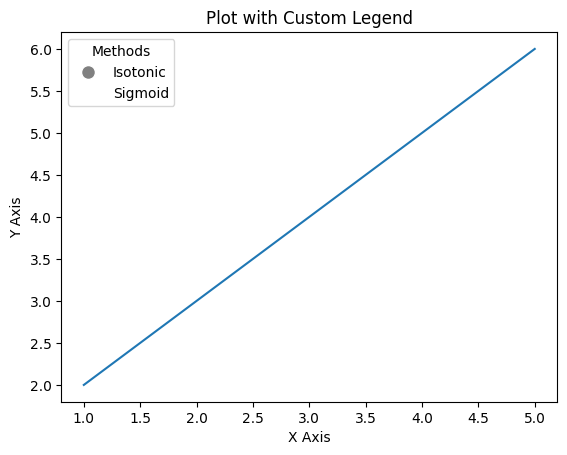

In [202]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a figure and axis
fig, ax = plt.subplots()

# Example plot (optional, for context)
x = [1, 2, 3, 4, 5]
y = [2, 3, 4, 5, 6]
ax.plot(x, y, label='Example Line')

# Create custom legend handles
custom_legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Isotonic'),
    Line2D([0], [0], marker='x', color='w', markerfacecolor='gray', markersize=10, label='Sigmoid')
]

# Add custom legend to the plot
ax.legend(handles=custom_legend_handles, title='Methods', loc='upper left')

# Add axis labels and title
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_title('Plot with Custom Legend')

# Show the plot
plt.show()

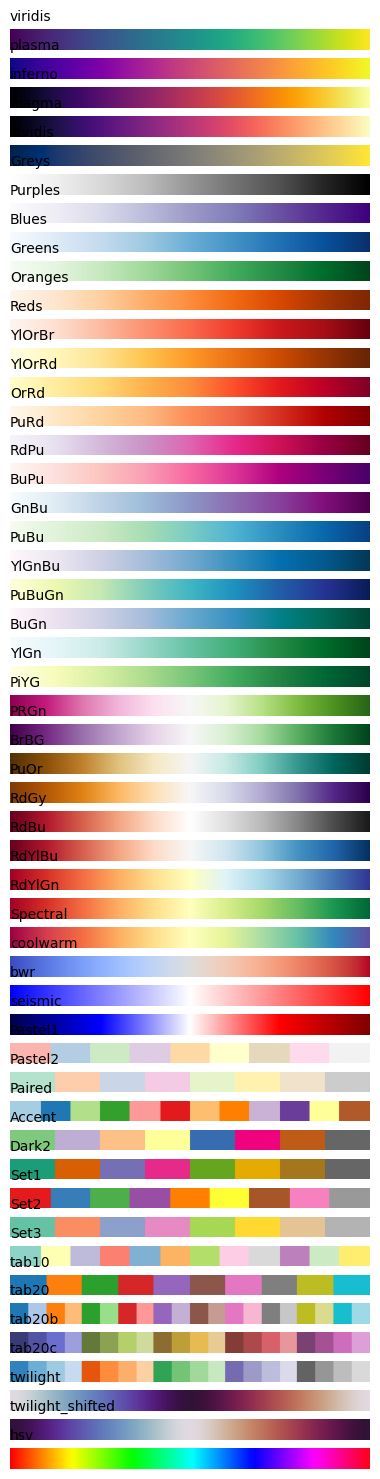

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# List of colormaps to display
colormaps = [
    "viridis",
    "plasma",
    "inferno",
    "magma",
    "cividis",
    "Greys",
    "Purples",
    "Blues",
    "Greens",
    "Oranges",
    "Reds",
    "YlOrBr",
    "YlOrRd",
    "OrRd",
    "PuRd",
    "RdPu",
    "BuPu",
    "GnBu",
    "PuBu",
    "YlGnBu",
    "PuBuGn",
    "BuGn",
    "YlGn",
    "PiYG",
    "PRGn",
    "BrBG",
    "PuOr",
    "RdGy",
    "RdBu",
    "RdYlBu",
    "RdYlGn",
    "Spectral",
    "coolwarm",
    "bwr",
    "seismic",
    "Pastel1",
    "Pastel2",
    "Paired",
    "Accent",
    "Dark2",
    "Set1",
    "Set2",
    "Set3",
    "tab10",
    "tab20",
    "tab20b",
    "tab20c",
    "twilight",
    "twilight_shifted",
    "hsv",
]

# Create a figure and axis
fig, axes = plt.subplots(nrows=len(colormaps), figsize=(6, len(colormaps) * 0.3))

# Display each colormap
for ax, cmap in zip(axes, colormaps):
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))
    ax.imshow(gradient, aspect="auto", cmap=plt.get_cmap(cmap))
    ax.set_axis_off()
    ax.set_title(cmap, fontsize=10, loc="left")

# Adjust layout
plt.subplots_adjust(left=0.2, right=0.8, top=0.98, bottom=0.02, hspace=0.4)
plt.show()